# Loading model

In [1]:
import io
import os
import pickle
import tarfile
import urllib
from pathlib import Path

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.linear_model import LogisticRegression
import torch
import torchvision.transforms.functional as TF
from tqdm import tqdm
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image
from huggingface_hub import login

def load_hf_token(env_filename: str = ".env", key: str = "HF_TOKEN") -> str | None:
    search_roots = [Path.cwd(), *Path.cwd().parents]
    for root in search_roots:
        env_file = root / env_filename
        if not env_file.exists():
            continue
        for raw_line in env_file.read_text(encoding="utf-8").splitlines():
            line = raw_line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            env_key, env_value = line.split("=", 1)
            if env_key.strip() == key:
                return env_value.strip().strip('"').strip("'")
    return os.getenv(key)

hf_token = load_hf_token()
if not hf_token:
    raise EnvironmentError("HF_TOKEN not found. Add it to .env or export it in the environment.")
login(token=hf_token)
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"   
MODEL_NAME = "dinov3_vith16plus"

device = "cuda:2" if torch.cuda.is_available() else "cpu"
local_dir = './models/dinov3_pretrained/'
pretrained_model_name = f'facebook/dinov3-vith16plus-pretrain-lvd1689m'

processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name,
    cache_dir=local_dir)

model = AutoModel.from_pretrained(
    pretrained_model_name, 
    device_map=device, 
    cache_dir=local_dir
)
model.to(device)
model.eval() 

/home/nas2/Workspace/Aaron/server2_envs/SAM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 615/615 [00:07<00:00, 78.59it/s, Materializing param=norm.weight]                       


DINOv3ViTModel(
  (embeddings): DINOv3ViTEmbeddings(
    (patch_embeddings): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
  )
  (rope_embeddings): DINOv3ViTRopePositionEmbedding()
  (layer): ModuleList(
    (0-31): 32 x DINOv3ViTLayer(
      (norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (attention): DINOv3ViTAttention(
        (k_proj): Linear(in_features=1280, out_features=1280, bias=False)
        (v_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (q_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (o_proj): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (layer_scale1): DINOv3ViTLayerScale()
      (drop_path): Identity()
      (norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (mlp): DINOv3ViTGatedMLP(
        (gate_proj): Linear(in_features=1280, out_features=5120, bias=True)
        (up_proj): Linear(in_features=1280, out_features=5120, bias=True)
        (down_proj

## 本地權重 (選用)

In [ ]:

# print(f"正在初始化模型架構: {pretrained_model_name}")

# LOCAL_WEIGHTS_PATH = "./models/pretrain/chicken_12500.pth"
# processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
# model = AutoModel.from_pretrained(pretrained_model_name)
# print(f"正在讀取本地權重: {LOCAL_WEIGHTS_PATH}")

# checkpoint = torch.load(LOCAL_WEIGHTS_PATH, map_location='cpu')
# if "model" in checkpoint:
#     state_dict = checkpoint["model"]
# elif "state_dict" in checkpoint:
#     state_dict = checkpoint["state_dict"]
# else:
#     state_dict = checkpoint # 如果整個檔案就是權重

# new_state_dict = {}
# for k, v in state_dict.items():
#     if k.startswith("module."):
#         new_state_dict[k[7:]] = v
#     else:
#         new_state_dict[k] = v
# state_dict = new_state_dict

# msg = model.load_state_dict(state_dict, strict=False)
# print("權重載入結果:", msg)

# # Move to GPU
# model.to(device)
# model.eval() 

# print("模型已準備就緒！")

## Parameters and functions

In [2]:
PATCH_SIZE = 16
IMAGE_SIZE = 3600

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}

# ==== 廢用 (分割前後景用) ====
save_root = '.'
model_path = os.path.join(save_root, "./models/fg_classifier.pkl")
with open(model_path, 'rb') as file:
    clf = pickle.load(file)
# ============================
    
n_layers = MODEL_TO_NUM_LAYERS[MODEL_NAME]
patch_quant_filter = torch.nn.Conv2d(1, 1, PATCH_SIZE, stride=PATCH_SIZE, bias=False)
patch_quant_filter.weight.data.fill_(1.0 / (PATCH_SIZE * PATCH_SIZE))


# image resize transform to dimensions divisible by patch size
def resize_transform( mask_image:Image, image_size:int = IMAGE_SIZE,patch_size: int = PATCH_SIZE,) -> torch.Tensor:
    w, h = mask_image.size
    print(f"Oringinal image size : ({w},{h})")
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    print(f"Patches setting  : ({w_patches},{h_patches})")
    print(f"TF.resize setting  : ({w_patches * patch_size},{h_patches * patch_size})")
    return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))

def extract_intermediate_feats_from_tensor(x, model):
    """
    x: (1, 3, H, W)，已經 resize + normalize 好的 image tensor
    回傳：feats: list 長度 = n_layers
          每個元素 shape: (B, dim, H_p, W_p)
    """
    if x.dim() == 3:
        x = x.unsqueeze(0)          # (1, 3, H, W)
    elif x.dim() != 4:
        raise ValueError(f"Expected input tensor with 3 or 4 dims, got shape {x.shape}")
    
    model.eval()

    # x 就是 pixel_values
    pixel_values = x.to(model.device)             # (1, 3, H, W)
    B, _, H, W = pixel_values.shape

    patch_size = model.config.patch_size          # e.g. 16
    num_reg    = getattr(model.config, "num_register_tokens", 0)
    n_layers   = model.config.num_hidden_layers   # e.g. 40

    H_p, W_p = H // patch_size, W // patch_size

    with torch.inference_mode():
        outputs = model(pixel_values=pixel_values,
                        output_hidden_states=True)

    hidden_states = outputs.hidden_states         # len = n_layers + 1
    hidden_states = hidden_states[1 : n_layers + 1]

    feats = []
    for hs in hidden_states:
        # hs: (B, 1 + R + P, dim)
        B, seq_len, dim = hs.shape

        # 拿掉 CLS + register，只留 patch tokens
        patch_tokens = hs[:, 1 + num_reg :, :]          # (B, P, dim)

        # (B, P, dim) → (B, dim, H_p, W_p)
        patch_tokens = patch_tokens.view(B, H_p, W_p, dim) \
                                     .permute(0, 3, 1, 2)  # (B, dim, H_p, W_p)

        feats.append(patch_tokens)

    return feats   # list of (B, dim, H_p, W_p)



/home/nas2/Workspace/Aaron/server2_envs/SAM/.venv/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## PCA Visualization 3-images 

Oringinal image size : (5616,3744)
Patches setting  : (337,225)
TF.resize setting  : (5392,3600)
number of feats:  32
Oringinal image size : (5616,3744)
Patches setting  : (337,225)
TF.resize setting  : (5392,3600)
number of feats:  32
Oringinal image size : (5801,3867)
Patches setting  : (337,225)
TF.resize setting  : (5392,3600)
number of feats:  32


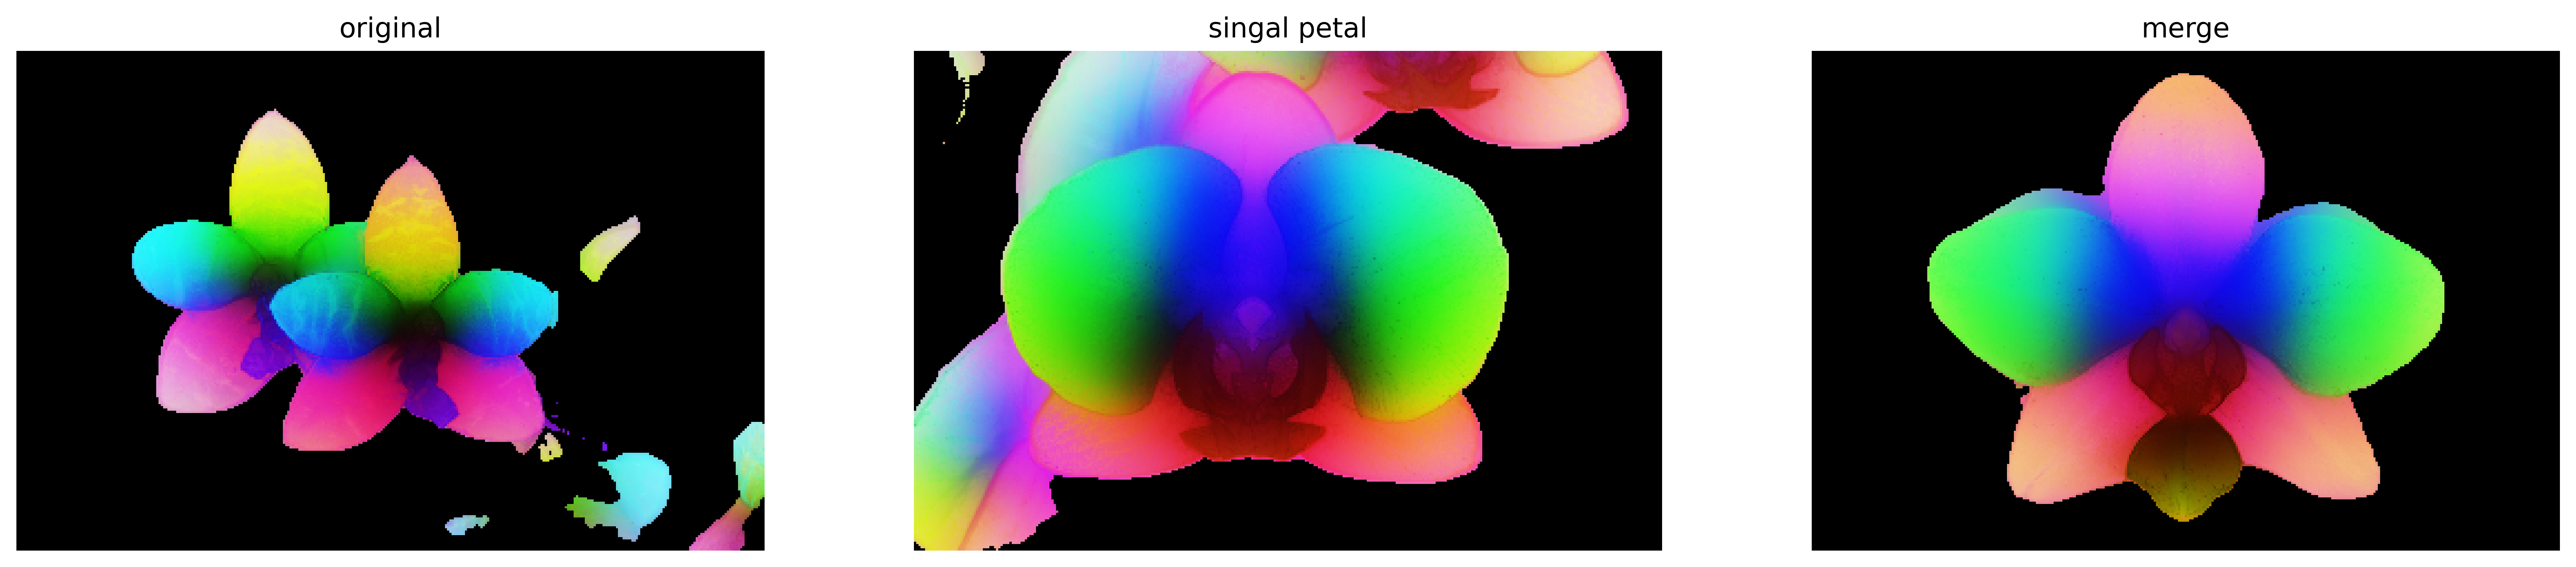

In [3]:
from sklearn.decomposition import PCA

ori_image_path = r"./Datasets/dump/IMG_4210.JPG"
petal_image_path = r"./Datasets/dump/IMG_4195.JPG"
merge_image_path = r"./Datasets/dump/merge1.png"
# r"/home/nas2/Workspace/Aaron/dinov3/images/merge.png"
image_paths = [ori_image_path, petal_image_path, merge_image_path]
name = ['original','singal petal', 'merge']
plt.figure(figsize=(20,20),dpi=500)
for i, image_path in enumerate(image_paths):
    ori_image = Image.open(image_path).convert("RGB")
    ori_image_resized = resize_transform(ori_image)
    ori_image_normalized = TF.normalize(ori_image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)

    with torch.inference_mode():
        with torch.autocast(device_type='cuda', dtype=torch.float32):
            feats = extract_intermediate_feats_from_tensor(ori_image_normalized, model)
            last_layer = feats[-1].squeeze().detach().cpu()
            dim = last_layer.shape[0]
            last_layer = last_layer.view(dim, -1).permute(1, 0)
            print("number of feats: ", len(feats))
            
    h_patches, w_patches = [int(d / PATCH_SIZE) for d in ori_image_resized.shape[1:]]

    fg_score = clf.predict_proba(last_layer)[:, 1].reshape(h_patches, w_patches)
    fg_score_mf = torch.from_numpy(signal.medfilt2d(fg_score, kernel_size=3))
    foreground_selection = fg_score_mf.view(-1) > 0.5
    fg_patches = last_layer[foreground_selection]
    pca = PCA(n_components=3, whiten=True)
    pca.fit(fg_patches)

    # apply the PCA, and then reshape
    projected_image = torch.from_numpy(pca.transform(last_layer.numpy())).view(h_patches, w_patches, 3)

    # multiply by 2.0 and pass through a sigmoid to get vibrant colors 
    projected_image = torch.nn.functional.sigmoid(projected_image.mul(2.0)).permute(2, 0, 1)

    # mask the background using the fg_score_mf
    projected_image *= (fg_score_mf.unsqueeze(0) > 0.5)

    # enjoy
    
    plt.subplot(1,3,i+1)
    plt.imshow(projected_image.permute(1, 2, 0))
    plt.title(name[i])
    plt.axis('off')
    
    
plt.show()

## PCA images generator (specific size)

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

target_h, target_w = 1000, 1000

upsampled_tensor = F.interpolate(
    projected_image.unsqueeze(0),    # [1, 3, H_patch, W_patch]
    size=(target_h, target_w),       # 目標大小 (例如 2400, 2400)
    mode='nearest',                  # <--- 改成這行！保留方塊感
    # align_corners=False            # nearest 模式不需要設定 align_corners
).squeeze(0)                         # [3, H_target, W_target]

final_image_blocky = upsampled_tensor.permute(1, 2, 0).numpy()

plt.imsave("4096.png", final_image_blocky)

## Visualization cross Large layer

Oringinal image size : (5616,3744)
Patches setting  : (337,225)
TF.resize setting  : (5392,3600)
✅ 獨立圖層與總覽圖皆已儲存至 ./Datasets/dump/


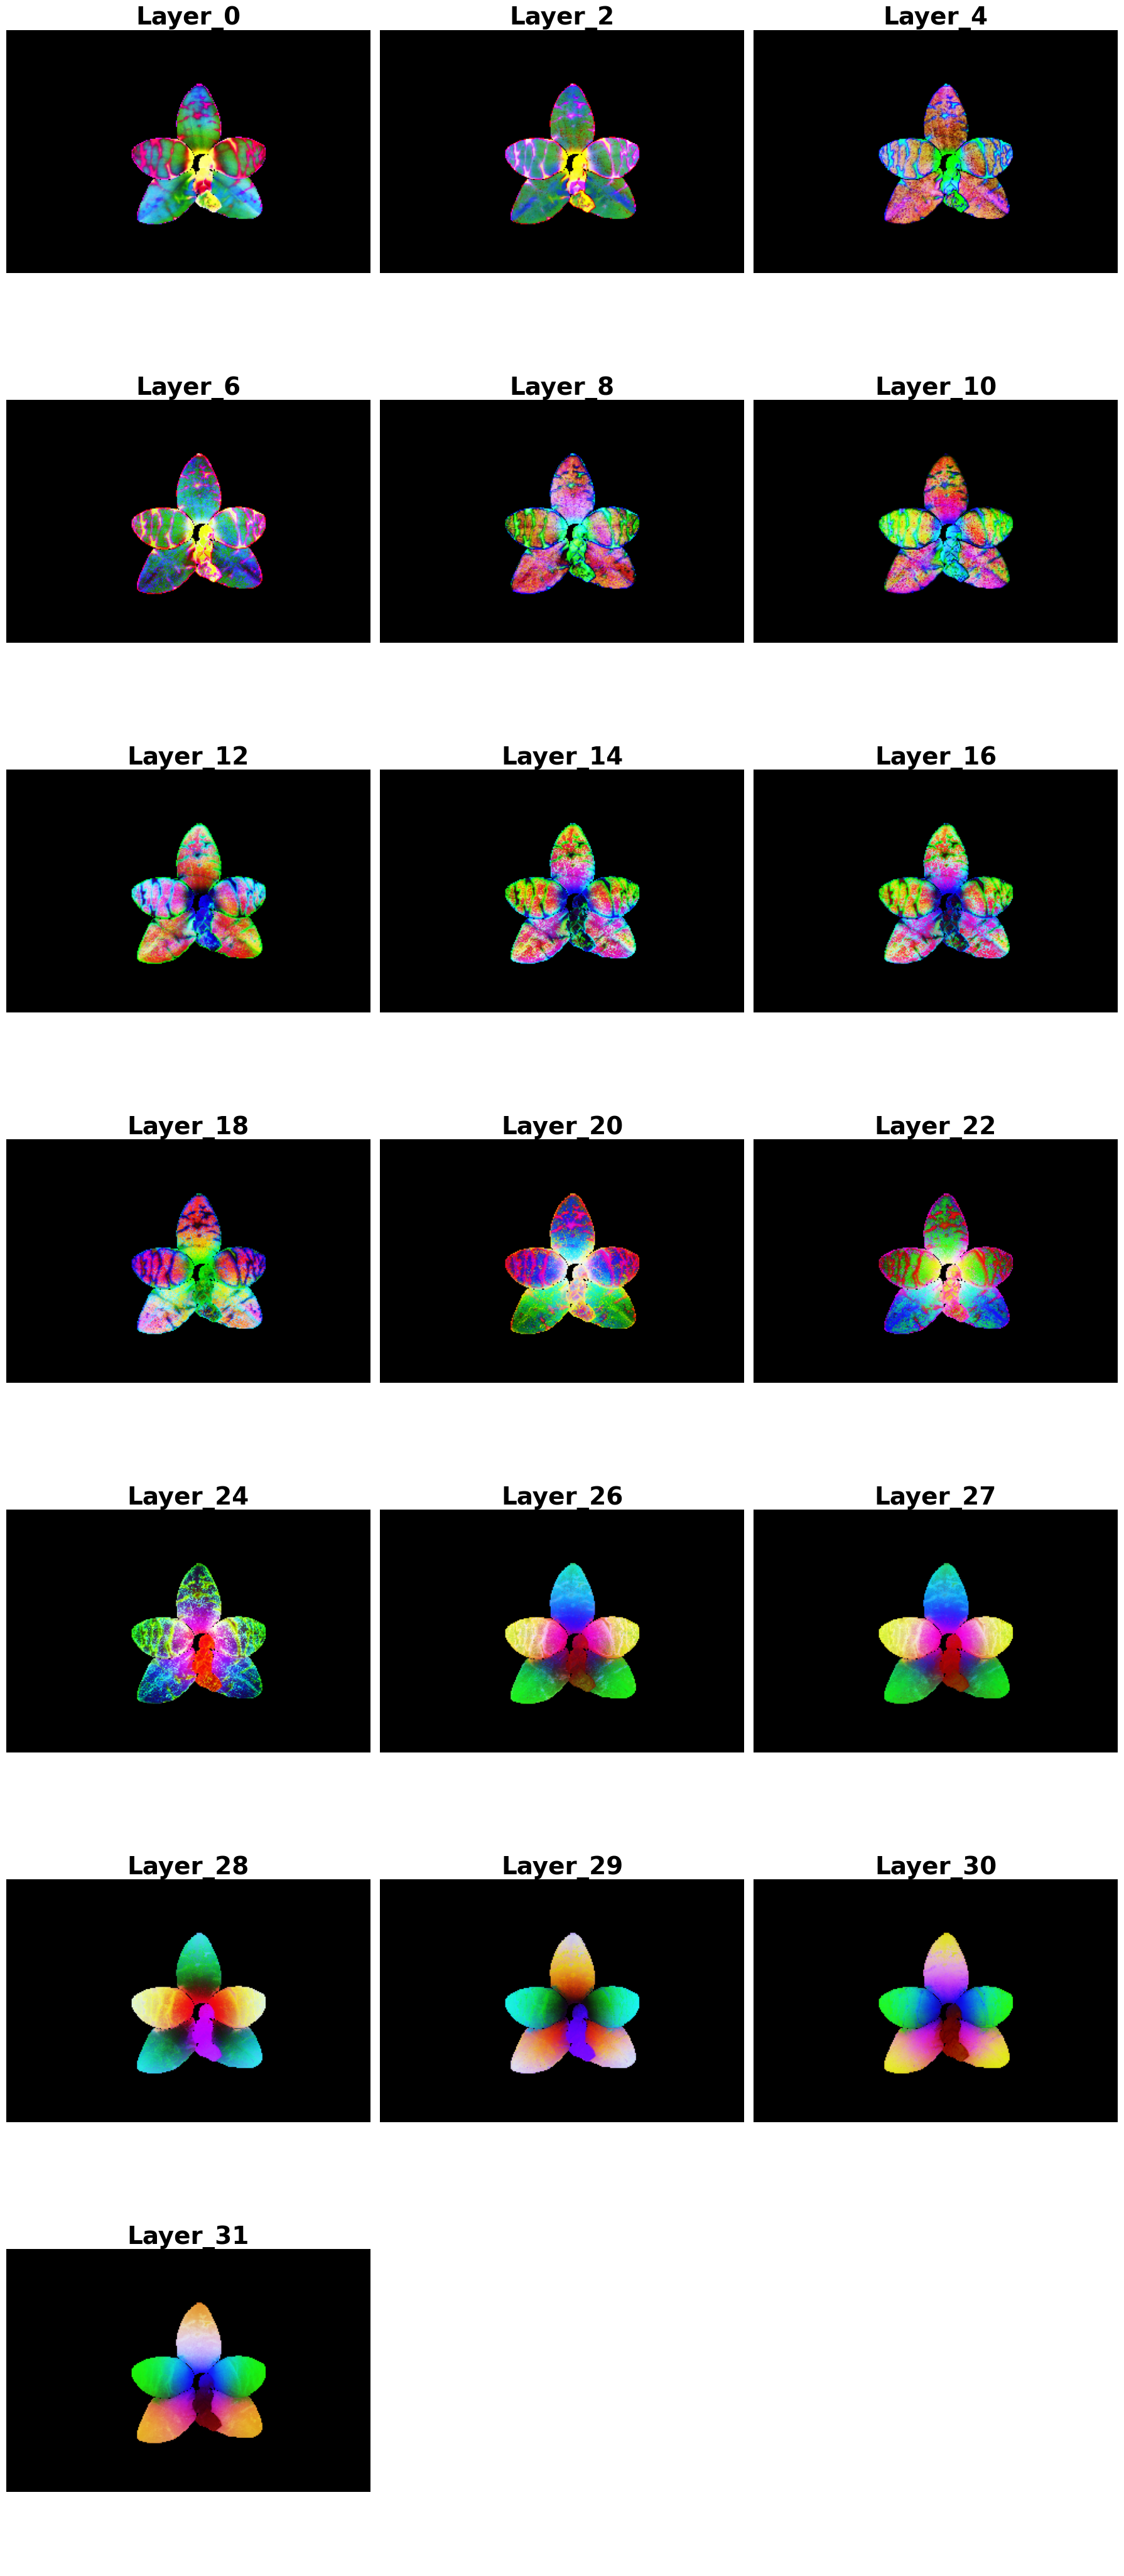

In [ ]:
import os
import math  
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms.functional as TF
from sklearn.decomposition import PCA

image_path = r"./Datasets/dataset/train/images/10001_C1-002.png"
mask_path = r"./Datasets/dataset/train/masks/10001_C1-002.png"

save_dir = "./Datasets/dump/"
os.makedirs(save_dir, exist_ok=True)

ori_image = Image.open(image_path).convert("RGB")
ori_image_resized = resize_transform(ori_image) 
ori_image_normalized = TF.normalize(ori_image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)
h_patches, w_patches = [int(d / PATCH_SIZE) for d in ori_image_resized.shape[1:]]


mask_image = Image.open(mask_path)
mask_resized = mask_image.resize((w_patches, h_patches), Image.NEAREST)
mask_np = np.array(mask_resized) > 0  
mask_1d = mask_np.flatten()         


layers_to_plot = [0,2,4,6,8,10,12,14,16,18,20,22,24,26,27,28,29,30,31]  

N_COLS = 3  
N_ROWS = math.ceil(len(layers_to_plot) / N_COLS) 

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6 * N_COLS, 6 * N_ROWS), dpi=100)
axes_flat = axes.flatten() 

with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):

        feats = extract_intermediate_feats_from_tensor(ori_image_normalized, model)

        for i, layer_idx in enumerate(layers_to_plot):
            curr_feat_raw = feats[layer_idx].squeeze().detach().cpu()
            dim_curr = curr_feat_raw.shape[0]
            
            curr_feat_vec = curr_feat_raw.view(dim_curr, -1).permute(1, 0)
            curr_feat_np = curr_feat_vec.numpy()

            fg_feats = curr_feat_np[mask_1d] 
            
            if fg_feats.shape[0] < 3:
                print(f"Layer {layer_idx}: Mask 內的特徵點太少，無法進行 3 維 PCA。")
                continue

            pca = PCA(n_components=3, whiten=True)
            pca.fit(fg_feats)
            fg_pca_proj = pca.transform(fg_feats)

            pca_proj_full = np.zeros((curr_feat_np.shape[0], 3))

            pca_proj_full[mask_1d] = fg_pca_proj

            projected_image = torch.from_numpy(pca_proj_full).view(h_patches, w_patches, 3)

            projected_image = torch.nn.functional.sigmoid(
                projected_image.mul(2.0)
            ).permute(2, 0, 1)
            
            projected_image[:, ~mask_np] = 0.0

            fig_single, ax_single = plt.subplots(figsize=(6, 6), dpi=150)
            ax_single.imshow(projected_image.permute(1, 2, 0).numpy())
            layer_name = f"Layer_{layer_idx}"
            ax_single.set_title(layer_name, fontsize=28, fontweight='bold')
            ax_single.axis('off')
        
            save_path = os.path.join(save_dir, f"{layer_name}.png")
            fig_single.savefig(save_path, bbox_inches="tight", pad_inches=0.05)
            plt.close(fig_single)

            ax_grid = axes_flat[i]
            ax_grid.imshow(projected_image.permute(1, 2, 0).numpy())
            ax_grid.set_title(layer_name, fontsize=28, fontweight='bold')
            ax_grid.axis('off')

total_plots = len(layers_to_plot)
for j in range(total_plots, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()

grid_save_path = os.path.join(save_dir, "All_Layers_Grid.png")
fig.savefig(grid_save_path, bbox_inches="tight")
print(f"✅ 獨立圖層與總覽圖皆已儲存至 {save_dir}")

plt.show()

### check dataset

In [1]:
import os
import numpy as np
from PIL import Image

def find_unique_classes(base_dir):
    # 定義要掃描的 mask 資料夾路徑
    mask_folders = [
        os.path.join(base_dir, "train", "masks"),
        os.path.join(base_dir, "val", "masks")
    ]
    
    unique_classes = set()
    total_images_scanned = 0

    for folder in mask_folders:
        if not os.path.exists(folder):
            print(f"⚠️ 找不到資料夾: {folder}")
            continue
            
        print(f"📂 正在掃描資料夾: {folder} ...")
        
        # 取得資料夾內所有圖片檔案
        valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        mask_files = [f for f in os.listdir(folder) if f.lower().endswith(valid_extensions)]
        
        for filename in mask_files:
            file_path = os.path.join(folder, filename)
            try:
                # 讀取圖片，通常 mask 應該是單通道，保險起見我們不強制轉換以觀察原始值
                # 若確定是彩色 mask，可加上 .convert("L") 或 .convert("P")
                img = Image.open(file_path)
                img_array = np.array(img)
                
                # 取得這張圖片中所有的獨立像素值，並加入 set 中
                unique_values = np.unique(img_array)
                unique_classes.update(unique_values)
                
                total_images_scanned += 1
                
            except Exception as e:
                print(f"❌ 讀取檔案 {filename} 時發生錯誤: {e}")

    # 將結果轉為排序過的列表
    sorted_classes = sorted(list(unique_classes))
    
    print("\n" + "="*30)
    print("📊 掃描結果總結")
    print("="*30)
    print(f"總共掃描了 {total_images_scanned} 張 Mask 圖片。")
    print(f"共發現 {len(sorted_classes)} 種不同的類別 (像素值)。")
    print(f"類別列表: {sorted_classes}")
    
    # 簡單的防呆提醒
    if len(sorted_classes) > 255:
         print("⚠️ 警告：類別數量超過 255，請確認您的 Mask 圖片是否不小心儲存成了包含漸層的 RGB 格式。")
         
    return sorted_classes

# 執行腳本 (請確認 "./dataset" 是你的 dataset 根目錄)
if __name__ == "__main__":
    dataset_root = "./Datasets/dataset_cropped_19_5classes_LandR"  
    classes = find_unique_classes(dataset_root)

📂 正在掃描資料夾: ./Datasets/dataset_cropped_19_5classes_LandR/train/masks ...
📂 正在掃描資料夾: ./Datasets/dataset_cropped_19_5classes_LandR/val/masks ...

📊 掃描結果總結
總共掃描了 31 張 Mask 圖片。
共發現 8 種不同的類別 (像素值)。
類別列表: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7)]


In [2]:
import os
import numpy as np
from PIL import Image

mask_dir = "./Datasets/dataset_cropped_19_5classes_LandR/train/masks/"
vis_dir = "./Datasets/dataset_cropped_19_5classes_LandR/train_masks_visible/"
os.makedirs(vis_dir, exist_ok=True)

for filename in os.listdir(mask_dir):
    if filename.endswith(".png"):
        mask_path = os.path.join(mask_dir, filename)
        
        # 讀取原本全黑的 Mask
        mask = np.array(Image.open(mask_path))
        
        # 把數值放大 (例如 1 會變成 40，2 變成 80，這樣肉眼就看得到了)
        visible_mask = (mask * 40).astype(np.uint8)
        
        # 存到新資料夾
        Image.fromarray(visible_mask).save(os.path.join(vis_dir, filename))
        
print("轉換完成，現在可以去檔案總管看 masks_visible 資料夾了！")

轉換完成，現在可以去檔案總管看 masks_visible 資料夾了！


Oringinal image size : (4029,3319)
Patches setting  : (273,225)
TF.resize setting  : (4368,3600)
Concatenating layers: [-1, 6, 12]
Combined Feature Shape: torch.Size([61425, 3840])


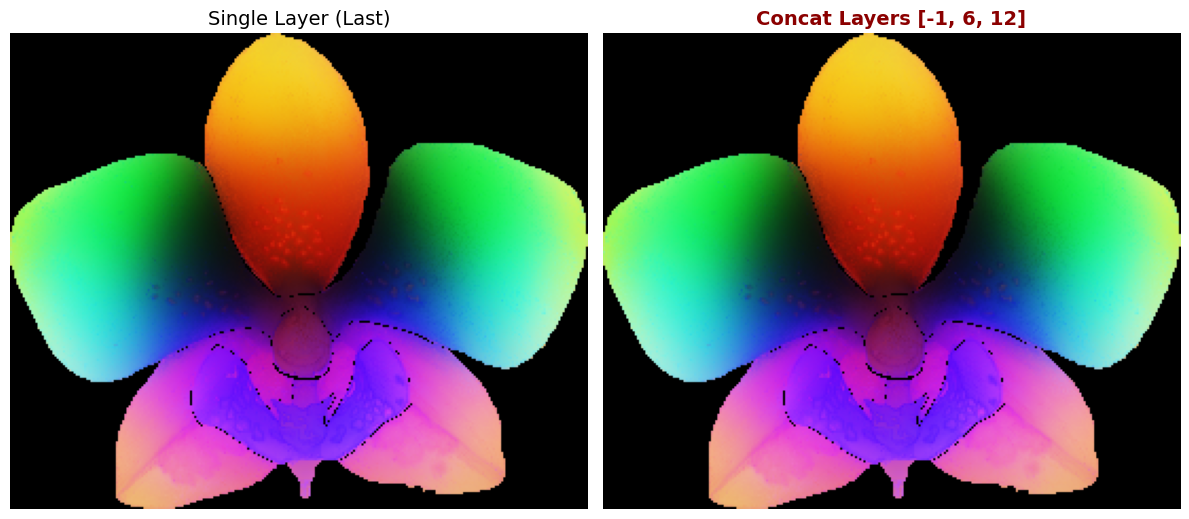

In [28]:
import os
import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoImageProcessor
from PIL import Image
import numpy as np
from sklearn.decomposition import PCA
# 已經不需要 scipy.signal，因為不用再對預測出來的熱度圖做平滑處理了
import torchvision.transforms.functional as TF

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# --- 假設前置變數已定義 (model, resize_transform, PATCH_SIZE 等) ---

image_path = r"./Datasets/dataset_cropped_12_5classes_LandR/train/images/1J5A3235_sam_crop.png"
# 👇 新增對應的 Mask 路徑
mask_path = r"./Datasets/dataset_cropped_12_5classes_LandR/train/masks/1J5A3235_sam_crop.png" 

ori_image = Image.open(image_path).convert("RGB")
ori_image_resized  = resize_transform(ori_image)
ori_image_normalized = TF.normalize(ori_image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)
h_patches, w_patches = [int(d / PATCH_SIZE) for d in ori_image_resized.shape[1:]]

# 定義您想要串接的層數 (例如：最後 3 層)
# 這樣做出來的向量維度會變成 3倍 (例如 768 * 3 = 2304)
layers_to_concat = [-1, 6, 12] 

# 原本寫 plt.figure() 又寫 plt.subplots() 會多產生一張空白圖，這裡幫您精簡成一行
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=100) 

with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        feats = extract_intermediate_feats_from_tensor(ori_image_normalized, model)
        
        # -------------------------------------------------------
        # 1. 準備前景遮罩 (改為讀取資料夾中真實的 Mask)
        # -------------------------------------------------------
        last_layer_raw = feats[-1].squeeze().detach().cpu()
        dim_last = last_layer_raw.shape[0]
        last_layer_vec = last_layer_raw.view(dim_last, -1).permute(1, 0)
        
        # 讀取並縮放 Mask
        mask_image = Image.open(mask_path)
        mask_resized = mask_image.resize((w_patches, h_patches), Image.NEAREST)
        
        # 只要數值 > 0 (1~4等類別) 就視為前景
        mask_2d_np = np.array(mask_resized) > 0
        mask_flat_np = mask_2d_np.flatten()
        
        # 轉為 PyTorch Tensor，以便後續與特徵 Tensor 進行乘法/篩選
        mask_2d = torch.from_numpy(mask_2d_np)
        mask_flat = torch.from_numpy(mask_flat_np)
        
        # -------------------------------------------------------
        # 2. 執行 Concatenation
        # -------------------------------------------------------
        feat_list = []
        print(f"Concatenating layers: {layers_to_concat}")
        
        for idx in layers_to_concat:
            # 取出單層
            f = feats[idx].squeeze().detach().cpu() # Shape: [Dim, H*W] or [Dim, H, W]
            
            # 確保形狀是 [N_tokens, Dim]
            if len(f.shape) == 3: 
                f = f.view(f.shape[0], -1) 
            
            f = f.permute(1, 0) # 變成 [N_tokens, Dim]
            feat_list.append(f)
            
        # 關鍵步驟：在 Dim 維度 (dim=1) 進行串接
        # Shape 變化: [N, 768] + [N, 768] + [N, 768] -> [N, 2304]
        concat_feat_vec = torch.cat(feat_list, dim=1)
        
        print(f"Combined Feature Shape: {concat_feat_vec.shape}")

        # -------------------------------------------------------
        # 3. 視覺化比較 (單層 vs Concat)
        # -------------------------------------------------------
        
        # === A. 畫單層 (Last Layer) 作為基準 ===
        pca_single = PCA(n_components=3, whiten=True)
        # 只 fit 前景
        pca_single.fit(last_layer_vec[mask_flat] if mask_flat.sum() > 0 else last_layer_vec)
        proj_single = pca_single.transform(last_layer_vec.numpy())
        img_single = torch.from_numpy(proj_single).view(h_patches, w_patches, 3)
        img_single = torch.nn.functional.sigmoid(img_single.mul(2.0)).permute(2, 0, 1)
        
        # 套用真實 Mask：將背景變為純黑
        img_single *= mask_2d.unsqueeze(0) 
        
        axes[0].imshow(img_single.permute(1, 2, 0))
        axes[0].set_title(f"Single Layer (Last)", fontsize=14)
        axes[0].axis('off')

        # === B. 畫 Concat Layer ===
        pca_concat = PCA(n_components=3, whiten=True)
        
        # 只 fit 前景 (輸入是 2304 維的向量)
        fg_concat = concat_feat_vec[mask_flat]
        pca_concat.fit(fg_concat if fg_concat.shape[0] > 0 else concat_feat_vec)
        
        proj_concat = pca_concat.transform(concat_feat_vec.numpy())
        img_concat = torch.from_numpy(proj_concat).view(h_patches, w_patches, 3)
        img_concat = torch.nn.functional.sigmoid(img_concat.mul(2.0)).permute(2, 0, 1)
        
        # 套用真實 Mask：將背景變為純黑
        img_concat *= mask_2d.unsqueeze(0)
        
        axes[1].imshow(img_concat.permute(1, 2, 0))
        axes[1].set_title(f"Concat Layers {layers_to_concat}", fontsize=14, fontweight='bold', color='darkred')
        axes[1].axis('off')

plt.tight_layout()
plt.show()

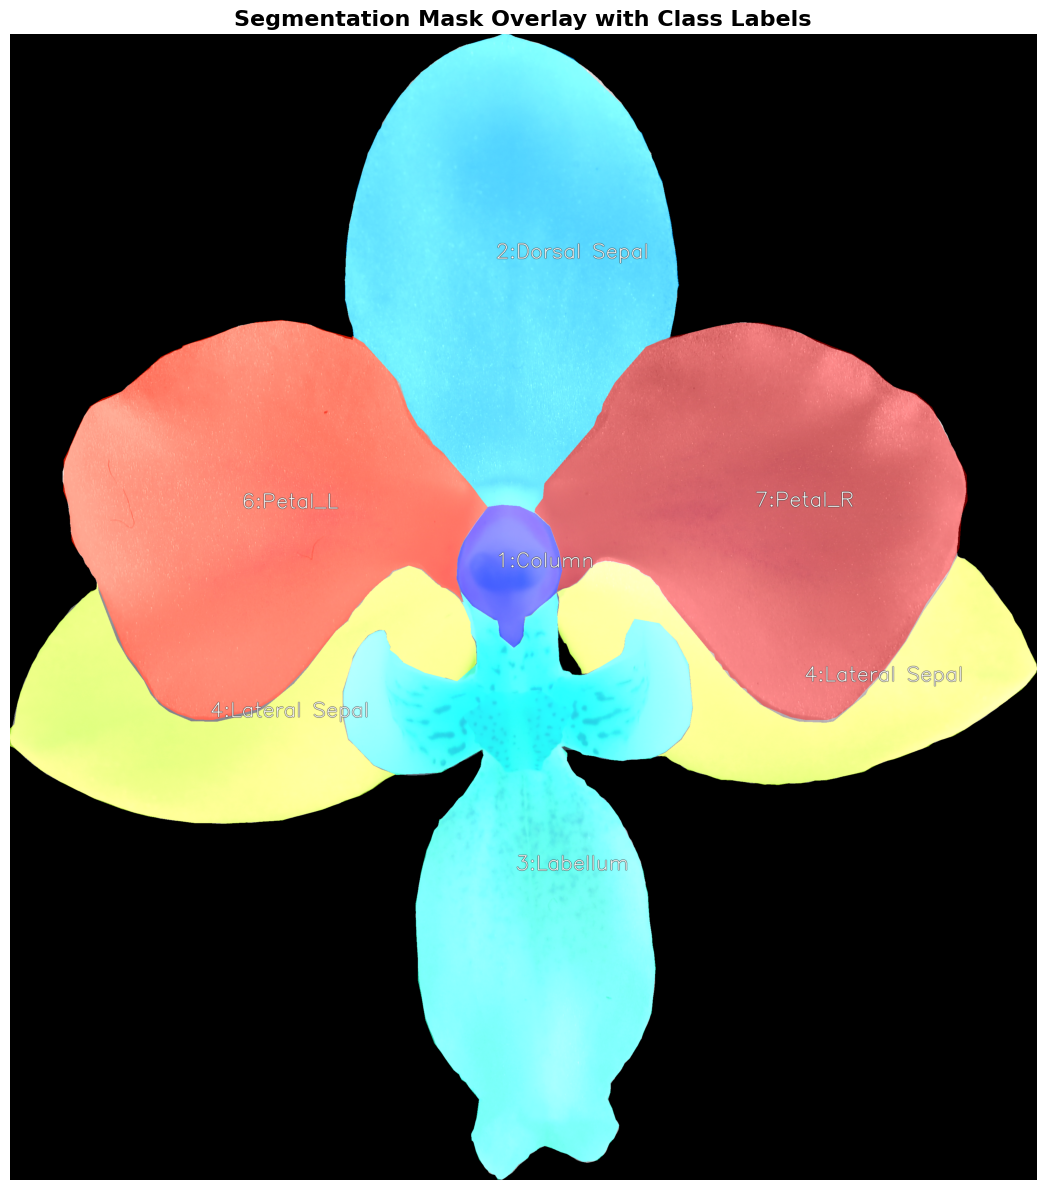

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 設定路徑與類別字典
# ==========================================
image_path = r"./Datasets/dataset_cropped_19_5classes_LandR/val/images/000_003_image.png"
mask_path = r"./Datasets/dataset_cropped_19_5classes_LandR/val/masks/000_003_image.png" 

# 定義你的 ID 與 Class Name 對應字典
class_mapping = {
    1: "Column",
    2: "Dorsal Sepal",
    3: "Labellum",
    4: "Lateral Sepal",
    5: "Petal",
    6: "Petal_L",
    7: "Petal_R"
}

# ==========================================
# 2. 讀取影像與遮罩 (含安全檢查)
# ==========================================
img_rgba = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
if img_rgba is None:
    raise FileNotFoundError("找不到原圖，請確認路徑與格式。")

channels = img_rgba.shape[2] if len(img_rgba.shape) == 3 else 1
if channels == 3:
    img_rgba = cv2.cvtColor(img_rgba, cv2.COLOR_BGR2RGBA)
elif channels == 1:
    img_rgba = cv2.cvtColor(img_rgba, cv2.COLOR_GRAY2RGBA)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
if mask is None:
    raise FileNotFoundError("找不到 Mask，請確認路徑。")

if img_rgba.shape[:2] != mask.shape[:2]:
    raise ValueError(f"尺寸不符！原圖尺寸 {img_rgba.shape[:2]} 與 Mask 尺寸 {mask.shape[:2]} 不一致。")

# ==========================================
# 3. 製作彩色疊合圖 (Overlay)
# ==========================================
# 取得底層 RGB 影像
img_rgb_content = cv2.cvtColor(img_rgba, cv2.COLOR_BGRA2RGB)

# 替 Mask 上色 (使用 JET 熱色圖)
max_id = np.max(mask) if np.max(mask) > 0 else 1
mask_normalized = (mask * (255 // max_id)).astype(np.uint8)
mask_colored = cv2.applyColorMap(mask_normalized, cv2.COLORMAP_JET)
mask_colored = cv2.cvtColor(mask_colored, cv2.COLOR_BGR2RGB)

# 進行影像疊加 (原圖 60%, 遮罩 40%)
overlay_img = cv2.addWeighted(img_rgb_content, 0.6, mask_colored, 0.8, 0)
# 背景 (ID=0) 不上色
overlay_img[mask == 0] = img_rgb_content[mask == 0]

# ==========================================
# 4. 尋找各區塊幾何中心點，並加上文字標示
# ==========================================
for class_id, class_name in class_mapping.items():
    # 獨立出當前類別的 Binary Mask
    binary_mask = np.where(mask == class_id, 255, 0).astype(np.uint8)
    
    # 尋找輪廓
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contours:
        # 過濾太小的雜訊區塊
        if cv2.contourArea(cnt) < 100:
            continue
            
        # 計算幾何矩 (Image Moments) 以取得中心點
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            
            # 準備文字內容
            text = f"{class_id}:{class_name}"
            
            # 設定字體參數
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 2  # 可依圖片大小調整文字比例
            thickness = 2
            
            # 為了讓文字在各種顏色的背景上都清楚，我們畫兩層：先畫黑色粗外框，再畫白色實心字
            # 1. 畫黑色外框線 (粗細加倍)
            cv2.putText(overlay_img, text, (cX - 40, cY), font, font_scale, (0, 0, 0), thickness + 2, cv2.LINE_AA)
            # 2. 畫白色文字
            cv2.putText(overlay_img, text, (cX - 40, cY), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

# ==========================================
# 5. 顯示單圖結果
# ==========================================
plt.figure(figsize=(12, 12))
plt.imshow(overlay_img)
plt.title("Segmentation Mask Overlay with Class Labels", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
!ls ./Datasets/dataset_cropped_12_5classes_LandR/val/images/

1J5A3622_sam_crop.png  1J5A4331_sam_crop.png  1J5A4853_sam_crop.png  @eaDir


In [18]:
import os
import shutil
import numpy as np
from PIL import Image
from tqdm import tqdm

def unify_mixed_masks(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    # 建立 Numpy 的 Lookup Table (LUT) 進行極速轉換
    lut = np.arange(256, dtype=np.uint8)
    
    # 設定轉換規則 (Old -> New)
    lut[1] = 6  # Petal_L
    lut[2] = 7  # Petal_R
    lut[3] = 2  # Dorsal Sepal
    lut[4] = 4  # Lateral Sepal (不變)
    lut[5] = 3  # Labellum
    lut[6] = 1  # Column

    filenames = [f for f in os.listdir(input_dir) if f.endswith('.png')]
    print(f"🔍 總共找到 {len(filenames)} 張 Mask，準備進行分類與轉換...")
    
    new_version_count = 0
    old_version_count = 0

    for filename in tqdm(filenames):
        filepath = os.path.join(input_dir, filename)
        save_path = os.path.join(output_dir, filename)
        
        # 讀取圖片並轉為 Numpy 陣列
        mask = np.array(Image.open(filepath).convert("L"))
        unique_vals = np.unique(mask)
        
        # 【核心邏輯】：根據您的保證，新版一定包含 7
        if 7 in unique_vals:
            # 這是新版，直接將原檔案複製過去，確保畫質與格式完全不變
            shutil.copy2(filepath, save_path)
            new_version_count += 1
        else:
            # 這是舊版，需要進行轉換
            # 防呆：處理可能有 255 背景的情況
            mask[mask == 255] = 0
            
            # 透過 LUT 一鍵套用轉換
            converted_mask = lut[mask]
            
            # 儲存轉換後的 Mask
            Image.fromarray(converted_mask).save(save_path)
            old_version_count += 1

    # 輸出統計報告
    print("\n✅ 處理完成！所有 Mask 已統一為新版格式 (8 classes)。")
    print("-" * 30)
    print(f"📁 輸出資料夾: {output_dir}")
    print(f"📊 發現並直接複製了 {new_version_count} 張【新版】Mask")
    print(f"📊 發現並成功轉換了 {old_version_count} 張【舊版】Mask")
    print("-" * 30)

# ==========================================
# 執行區塊
# ==========================================
if __name__ == "__main__":
    # 這裡填入您目前「新舊混雜」的那個資料夾路徑
    MIXED_MASKS_FOLDER = "./Datasets/test_dataset/masks/"
    
    # 這裡填入您想要儲存「統一乾淨」Mask 的新資料夾路徑
    UNIFIED_MASKS_FOLDER = "./Datasets/test_dataset/masks_1/"
    
    unify_mixed_masks(MIXED_MASKS_FOLDER, UNIFIED_MASKS_FOLDER)

🔍 總共找到 19 張 Mask，準備進行分類與轉換...


100%|██████████| 19/19 [00:03<00:00,  4.93it/s]


✅ 處理完成！所有 Mask 已統一為新版格式 (8 classes)。
------------------------------
📁 輸出資料夾: ./Datasets/test_dataset/masks_1/
📊 發現並直接複製了 19 張【新版】Mask
📊 發現並成功轉換了 0 張【舊版】Mask
------------------------------


In [21]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

def purify_entire_dataset(dataset_dir):
    splits = ['train', 'val']
    
    for split in splits:
        print(f"\n🚀 正在掃描並淨化 {split} 資料集...")
        
        # ==========================================
        # 1. 處理原始圖片 (Images) -> 確保為 3 通道 (RGB)
        # ==========================================
        image_dir = os.path.join(dataset_dir, split, 'images')
        if os.path.exists(image_dir):
            img_filenames = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
            img_fixed = 0
            
            for filename in tqdm(img_filenames, desc="Images (目標: RGB 3通道)"):
                filepath = os.path.join(image_dir, filename)
                img = Image.open(filepath)
                
                # 如果不是標準的 3 通道 RGB (例如是 4 通道 RGBA 或 單通道灰階)
                if img.mode != 'RGB':
                    if img.mode == 'RGBA':
                        # 建立純白背景來墊底，避免透明區塊變黑影響圖片特徵
                        background = Image.new('RGB', img.size, (255, 255, 255))
                        background.paste(img, mask=img.split()[3]) # 第 3 個通道是 Alpha
                        background.save(filepath)
                    else:
                        # 單通道灰階圖或其他格式，直接轉換
                        img.convert('RGB').save(filepath)
                    img_fixed += 1
            print(f"  👉 成功將 {img_fixed} 張原始圖片轉為標準 3 通道 (RGB)。")

        # ==========================================
        # 2. 處理標籤圖片 (Masks) -> 確保為 1 通道 (L)，且無幽靈數據
        # ==========================================
        mask_dir = os.path.join(dataset_dir, split, 'masks')
        if os.path.exists(mask_dir):
            mask_filenames = [f for f in os.listdir(mask_dir) if f.endswith('.png')]
            mask_fixed = 0
            
            for filename in tqdm(mask_filenames, desc="Masks (目標: L 單通道整數)"):
                filepath = os.path.join(mask_dir, filename)
                img = Image.open(filepath)
                arr = np.array(img)
                
                needs_fixing = False
                
                # 狀況 A: 4 通道 (RGBA) - 處理透明底幽靈數據
                if img.mode == 'RGBA' or arr.shape[-1] == 4:
                    r, g, b, a = arr[:,:,0], arr[:,:,1], arr[:,:,2], arr[:,:,3]
                    r[a == 0] = 0 # 將透明區域的標籤強制歸零 (背景)
                    clean_mask = r  # 直接取 R 通道作為類別 index
                    needs_fixing = True
                    
                # 狀況 B: 3 通道 (RGB) - 避免 convert("L") 的亮度公式破壞 index
                elif img.mode == 'RGB' or len(arr.shape) == 3:
                    clean_mask = arr[:,:,0] # 直接抽離 R 通道作為類別 index
                    needs_fixing = True
                
                # 如果原本就是完美的單通道 (L)，且形狀正確，就不做任何事
                elif img.mode == 'L' and len(arr.shape) == 2:
                    continue
                
                # 執行覆蓋存檔
                if needs_fixing:
                    # 存回單通道 L 模式，確保 Pytorch 讀取為 (H, W)
                    Image.fromarray(clean_mask).convert("L").save(filepath)
                    mask_fixed += 1
                    
            print(f"  👉 成功將 {mask_fixed} 張 Mask 清理並轉為純淨單通道 (L)。")

# ==========================================
# 執行區塊
# ==========================================
if __name__ == "__main__":
    # 換成你 Dataset 的主目錄路徑
    DATASET_DIR = "./Datasets/test_dataset/"
    
    purify_entire_dataset(DATASET_DIR)


🚀 正在掃描並淨化 train 資料集...


Images (目標: RGB 3通道): 100%|██████████| 19/19 [00:34<00:00,  1.83s/it]


  👉 成功將 8 張原始圖片轉為標準 3 通道 (RGB)。


Masks (目標: L 單通道整數): 100%|██████████| 19/19 [00:01<00:00, 15.78it/s]

  👉 成功將 0 張 Mask 清理並轉為純淨單通道 (L)。

🚀 正在掃描並淨化 val 資料集...
